# 📊 Sales Forecasting using Machine Learning

## 🔍 Introduction
The objective of this project is to forecast future sales using historical data.

Sales forecasting helps businesses in:
- Inventory planning
- Demand management
- Financial decision-making

In this project, we use Machine Learning to predict the next 30 days of sales.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 📉 Model Evaluation

- Used Mean Absolute Error (MAE)

MAE = 1756.65

This means that the model’s predictions are off by approximately 1756 units on average.

## 📈 Visualization

- Plotted past sales (smoothed)
- Plotted 30-day future forecast
- Visualization helps understand trends clearly

## 💼 Business Insights

- Sales show high fluctuations with no strong consistent trend
- Forecast indicates relatively stable future sales

### How businesses can use this:
- Plan inventory efficiently
- Avoid overstocking or understocking
- Manage demand and staffing
- Improve financial planning

## 🧹 Data Cleaning

- Loaded dataset using Pandas
- Handled encoding issues using 'latin1'
- Selected relevant columns (Order Date, Sales)
- Converted Order Date to datetime format
- Sorted data by date
- Aggregated sales by date to remove duplicates

In [2]:
sales = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## ⚙️ Feature Engineering

- Created TimeIndex to represent time progression
- Extracted Month from date to capture seasonal patterns

In [3]:
sales = sales[['Order Date', 'Sales']]
sales.head()

,Order Date,Sales
0,11/8/2016,261.9600
1,11/8/2016,731.9400
2,6/12/2016,14.6200
3,10/11/2015,957.5775
4,10/11/2015,22.3680


In [4]:
sales['Order Date'] = pd.to_datetime(sales['Order Date'])

In [5]:
sales = sales.sort_values(by='Order Date')

In [6]:
sales = sales.groupby('Order Date')['Sales'].sum().reset_index()

In [7]:
sales['TimeIndex'] = np.arange(len(sales))

In [8]:
sales['Month'] = sales['Order Date'].dt.month

## 🤖 Model Building

- Used Linear Regression model
- Trained model using TimeIndex and Month features
- Model learns the trend in sales over time

In [9]:
X = sales[['TimeIndex', 'Month']]
y = sales['Sales']

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [10]:
future_index = np.arange(len(sales), len(sales) + 30)

future_df = pd.DataFrame({'TimeIndex': future_index})

future_dates = pd.date_range(start=sales['Order Date'].max(), periods=30)
future_df['Order Date'] = future_dates

In [11]:
future_df['Month'] = future_df['Order Date'].dt.month

In [12]:
future_sales = model.predict(future_df[['TimeIndex', 'Month']])

In [13]:
sales['Sales_Smoothed'] = sales['Sales'].rolling(window=7).mean()

## 📉 Model Evaluation

- Used Mean Absolute Error (MAE)

MAE = 1756.65

This means that the model’s predictions are off by approximately 1756 units on average.

In [15]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X)
mae = mean_absolute_error(y, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 1464.9394739428706


In [17]:
future_df['Predicted Sales'] = future_sales
future_df.to_csv("future_sales.csv", index=False)

## 📈 Visualization

- Plotted past sales (smoothed)
- Plotted 30-day future forecast
- Visualization helps understand trends clearly

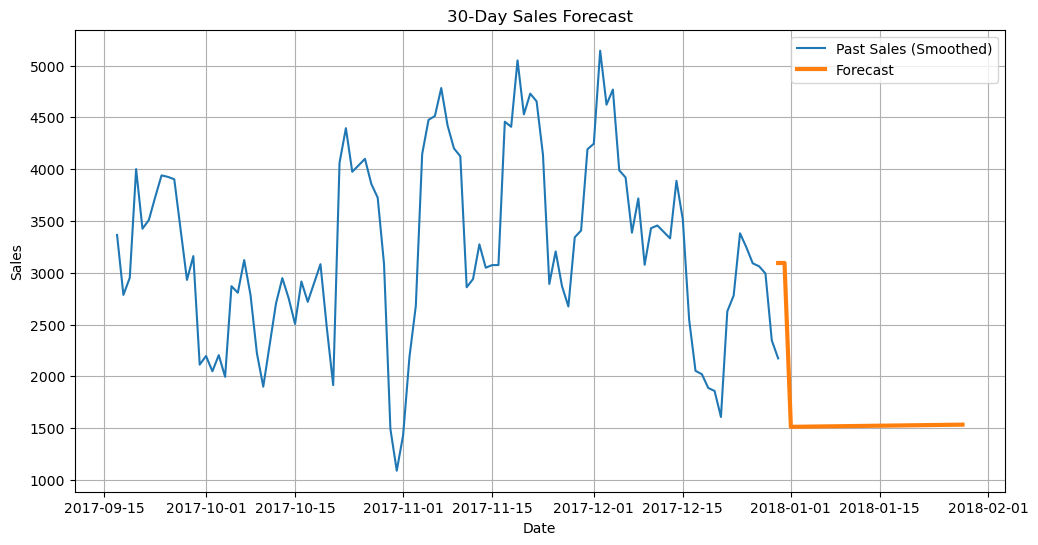

In [19]:
plt.figure(figsize=(12,6))

recent_data = sales.tail(100)

plt.plot(recent_data['Order Date'], recent_data['Sales_Smoothed'], label="Past Sales (Smoothed)")
plt.plot(future_df['Order Date'], future_sales, label="Forecast", linewidth=3)

plt.legend()
plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("30-Day Sales Forecast")

plt.grid(True)

plt.savefig("forecast.png", dpi=300)
plt.show()

## 💼 Business Insights

- Sales show high fluctuations with no strong consistent trend
- Forecast indicates relatively stable future sales

### How businesses can use this:
- Plan inventory efficiently
- Avoid overstocking or understocking
- Manage demand and staffing
- Improve financial planning